# Project: Computational immunophenotyping of biomaterial-induced foreign body response
---
**Notebook**: 01_qc_preprocessing

**Dataset:** [GSE203099](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE203099)  
**Author:** *Chinonye Precious Anams*


## 1. Biological context and objective

### 1.1 The Foreign Body Response (FBR)
The **Foreign Body Response (FBR)** to implanted biomaterials is characterized by a coordinated immune and stromal reaction that can culminate in chronic inflammation and fibrosis. 

Traditional bulk analysis often masks the heterogeneity of this response; however, **Single-cell RNA sequencing (scRNA-seq)** enables unbiased resolution of the diverse immune and stromal populations that emerge at the biomaterial–tissue interface.

### 1.2 Analysis Objectives
The objective of this analysis is to process the **GSE203099** dataset to establish a high-quality global cellular landscape. This will be achieved through:

1.  **Quality Control (QC):** Filtering cells based on library size, gene counts, and mitochondrial gene expression.
2.  **Normalization:** Correcting for technical variations to make gene expression comparable across cells.
3.  **Unsupervised Clustering:** Grouping cells with similar transcriptomic profiles using **Leiden** algorithm.

> **Significance:** These steps serve as the essential foundation for downstream **immunophenotyping** and state-level analyses, allowing us to pinpoint the exact cellular drivers of biomaterial-induced fibrosis.

---


### Metadata

In [1]:
"""
Project: Computational immunophenotyping of biomaterial-induced foreign body response
Dataset: GSE203099
Aim: Identify immune and fibroblast cell states associated with biomaterial implantation
Author: Chinonye Precious Anams
"""

'\nProject: Computational immunophenotyping of biomaterial-induced foreign body response\nDataset: GSE203099\nAim: Identify immune and fibroblast cell states associated with biomaterial implantation\nAuthor: Chinonye Precious Anams\n'

## 2. Environment setup and imports

In [2]:
from pathlib import Path
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
qc_dir = Path("../figures/qc")
qc_dir.mkdir(parents=True, exist_ok=True)

hvg_dir = Path("../figures/hvg")
hvg_dir.mkdir(parents=True, exist_ok=True)

dimred_dir = Path("../figures/dimred")
dimred_dir.mkdir(parents=True, exist_ok=True)

clustering_dir = Path("../figures/clustering")
clustering_dir.mkdir(parents=True, exist_ok=True)

annotation_dir = Path("../figures/annotation")
annotation_dir.mkdir(parents=True, exist_ok=True)

In [4]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100)

## 3. Dataset overview and data loading

### 3.1 Dataset source and structure
This analysis uses publicly available single-cell RNA-seq data from GEO accession [GSE203099](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE203099), profiling immune and stromal cells isolated from tissue surrounding implanted biomaterials. The dataset captures transcriptional responses at the biomaterial–tissue interface, enabling investigation of immune heterogeneity induced by different material conditions.


### 3.2 Load raw count matrix

In [5]:
PROJECT_ROOT = Path("..")

counts_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "GSE203099"
    / "GSE203099_raw_counts.txt.gz"
)

counts = pd.read_csv(
    counts_path,
    sep="\t",
    index_col=0
)

### 3.3 Initial inspection of raw data

In [6]:
counts.shape

(21617, 41191)

In [7]:
counts.head()

,AAACCCAAGACCAGAC-1,AAACCCAAGATGAATC-1,AAACCCACAAGTATAG-1,AAACCCAGTACAGAAT-1,AAACCCAGTACTAAGA-1,AAACCCAGTTAAGGAT-1,AAACCCAGTTAAGGGC-1,AAACCCAGTTCGCGTG-1,AAACGAAAGCTGGTGA-1,AAACGAACAACCACGC-1,...,TTTGACTTCTAGTACG-5,TTTGATCGTTCTCAGA-5,TTTGATCTCACAGAGG-5,TTTGATCTCATTGCTT-5,TTTGATCTCGCTGATA-5,TTTGATCTCTGTCTCG-5,TTTGGAGCATTGTAGC-5,TTTGGAGTCAAATAGG-5,TTTGGTTAGAGGCTGT-5,TTTGGTTCAGCAGATG-5
Xkr4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Gm19938,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Rp1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Sox17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Gm37587,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
counts.index[:5]

Index(['Xkr4', 'Gm19938', 'Rp1', 'Sox17', 'Gm37587'], dtype='object')

In [9]:
counts.columns[:5]

Index(['AAACCCAAGACCAGAC-1', 'AAACCCAAGATGAATC-1', 'AAACCCACAAGTATAG-1',
       'AAACCCAGTACAGAAT-1', 'AAACCCAGTACTAAGA-1'],
      dtype='object')

### 3.4 Transpose and create AnnData object

In [10]:
counts = counts.T

In [11]:
adata = sc.AnnData(counts)
adata

AnnData object with n_obs × n_vars = 41191 × 21617

In [12]:
adata.n_obs, adata.n_vars

(41191, 21617)

In [13]:
adata.var_names[:30]

Index(['Xkr4', 'Gm19938', 'Rp1', 'Sox17', 'Gm37587', 'Mrpl15', 'Lypla1',
       'Tcea1', 'Rgs20', 'Atp6v1h', 'Rb1cc1', '4732440D04Rik', 'St18',
       'Pcmtd1', 'Gm26901', 'Sntg1', 'Rrs1', 'Adhfe1', '2610203C22Rik', 'Vxn',
       'Mybl1', 'Vcpip1', '1700034P13Rik', 'Sgk3', 'Mcmdc2', 'Snhg6', 'Tcf24',
       'Ppp1r42', 'Cops5', 'Cspp1'],
      dtype='object')

In [14]:
for gene in ["Lyz2", "Cd68", "Col1a1", "Actb"]:
    print(gene, gene in adata.var_names)

Lyz2 True
Cd68 True
Col1a1 True
Actb True


## 4. Quality control

### 4.1 Rationale for QC in implanted tissue
Tissue collected from biomaterial implantation sites is prone to cellular stress, mechanical damage, and enzymatic digestion artifacts. Quality control filtering is therefore essential to remove low-quality or dying cells that could confound biological interpretation of immune and stromal programs.


### 4.2 Identification of mitochondrial genes

In [15]:
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")

### 4.3 Compute QC metrics

In [16]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

### 4.4 QC visualization

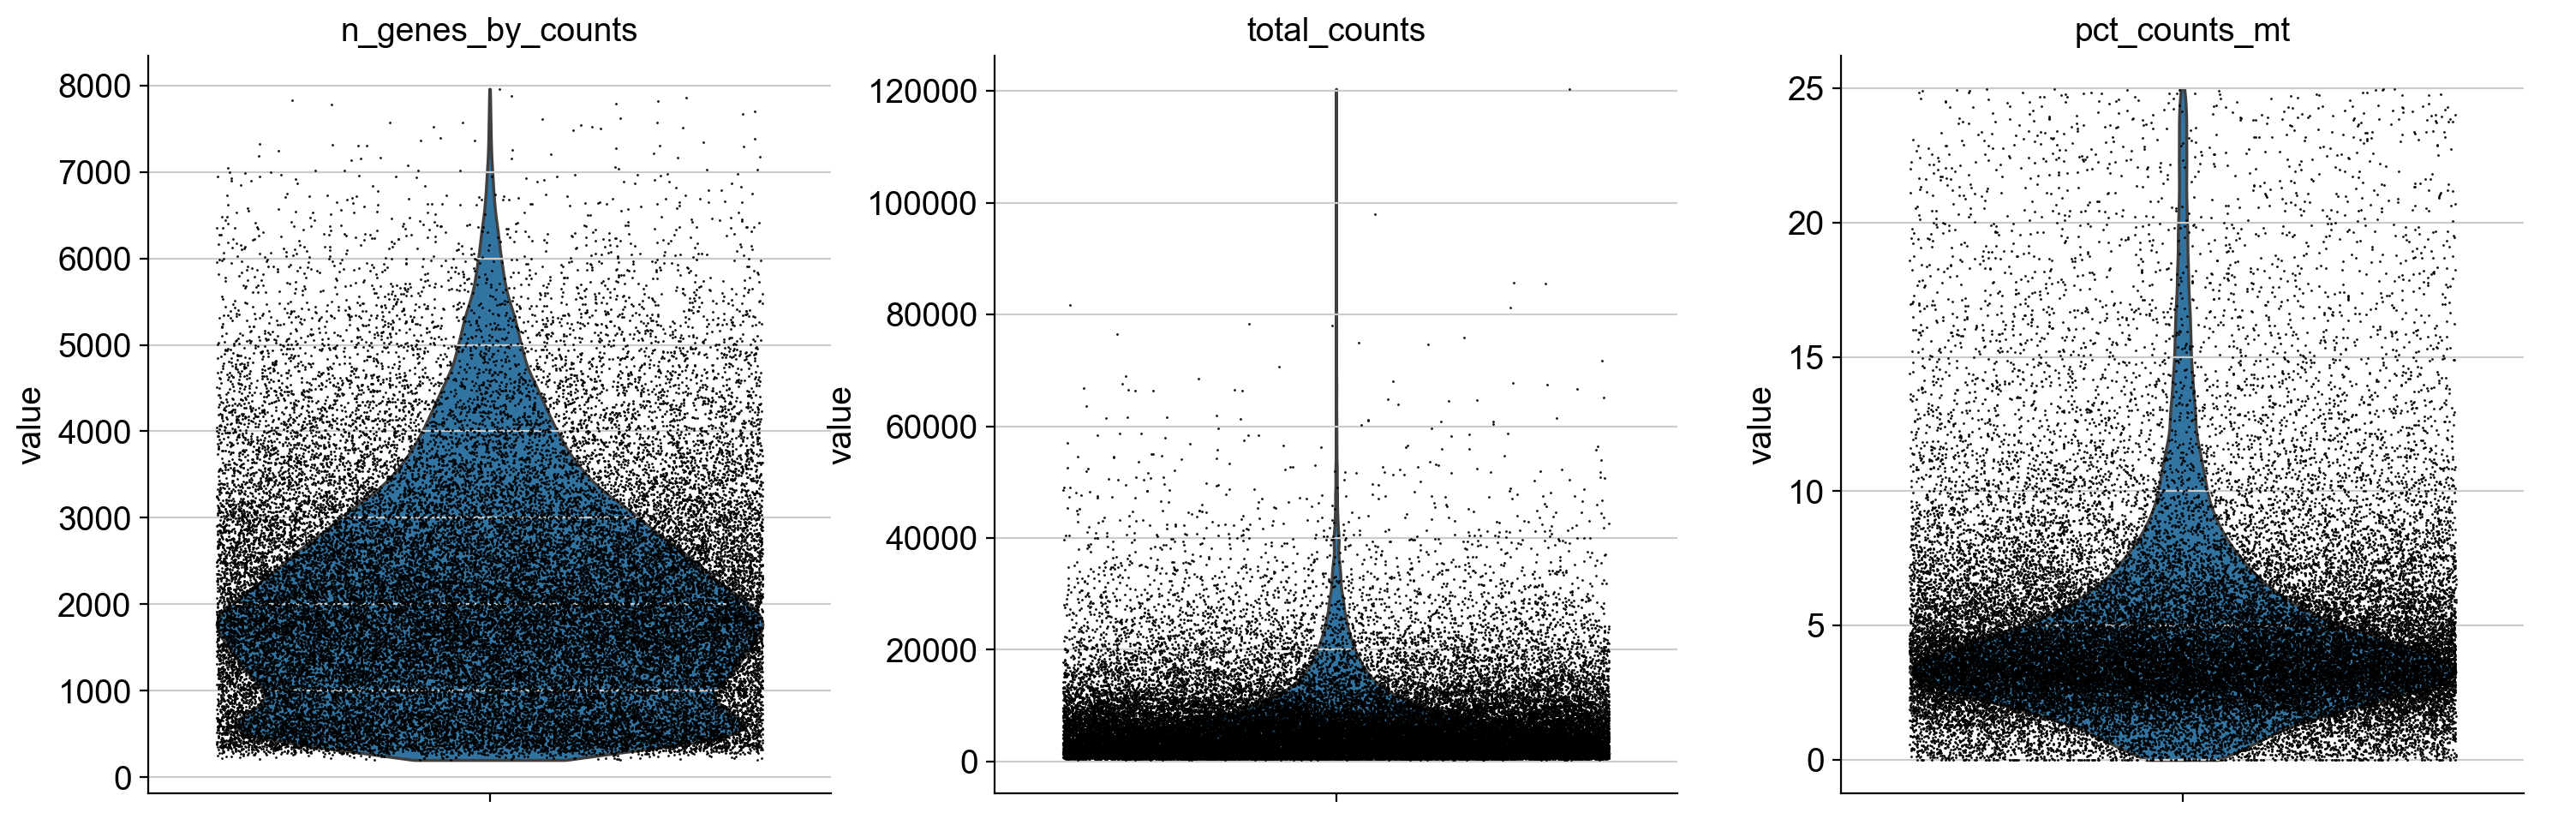

In [17]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    show=False   
)

plt.savefig(qc_dir / "qc_violin.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

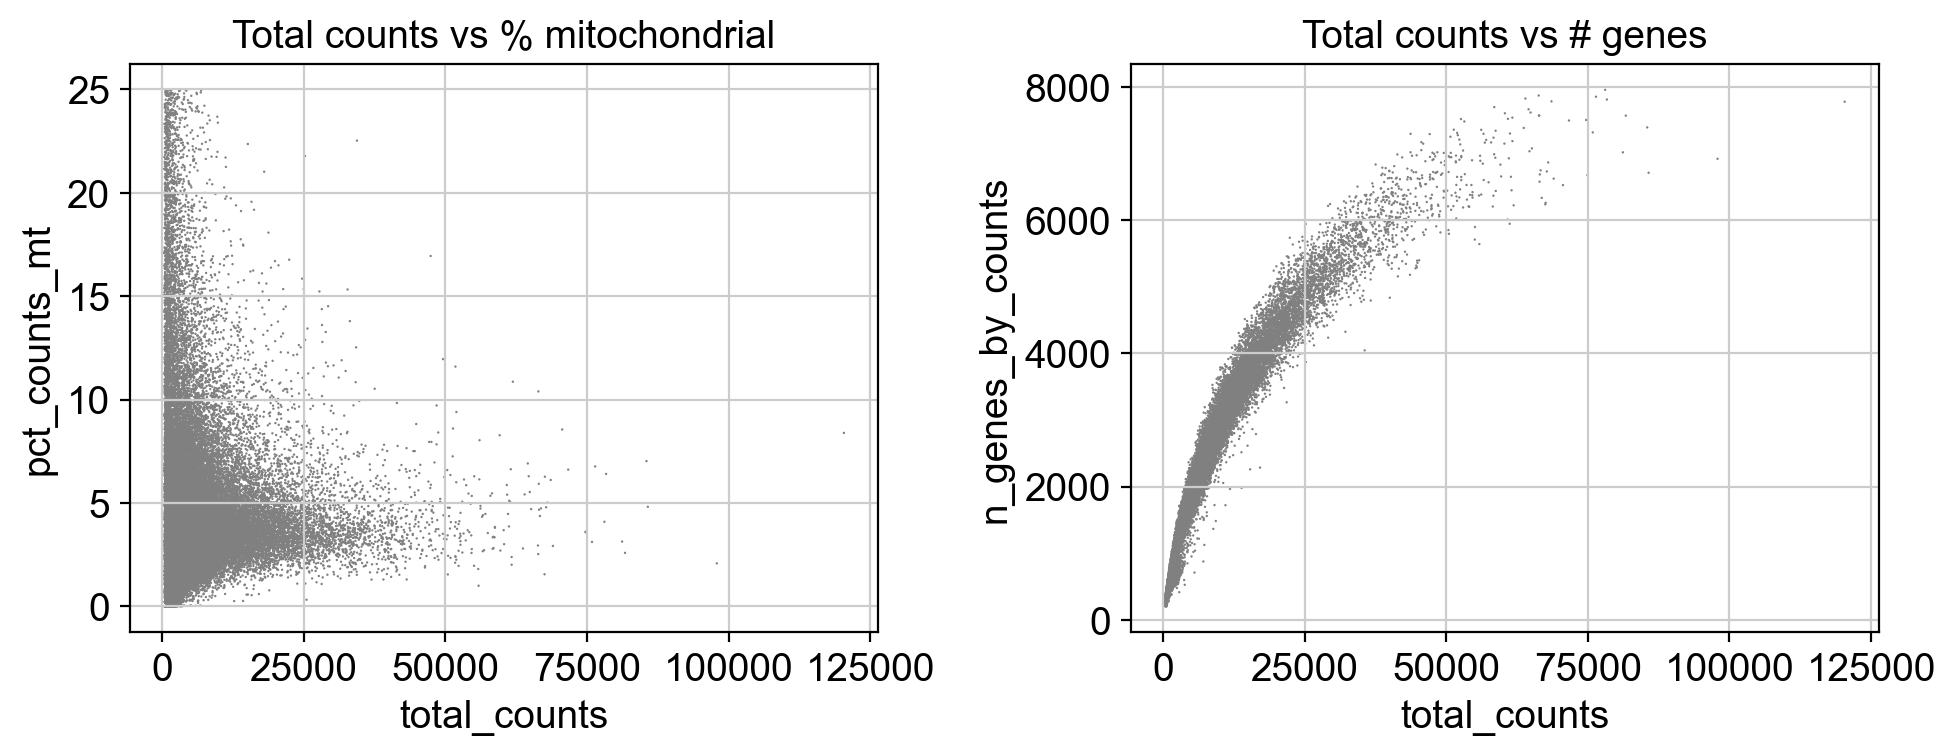

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Scatter 1
sc.pl.scatter(
    adata,
    x="total_counts",
    y="pct_counts_mt",
    ax=axes[0],
    show=False
)
axes[0].set_title("Total counts vs % mitochondrial")

# Scatter 2
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    ax=axes[1],
    show=False
)
axes[1].set_title("Total counts vs # genes")

plt.tight_layout()
plt.savefig(
    qc_dir / "qc_scatter_total_counts_combined.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 4.5 QC filtering and justification

In [19]:
adata = adata[
    (adata.obs.n_genes_by_counts > 300) &
    (adata.obs.n_genes_by_counts < 6000) &
    (adata.obs.pct_counts_mt < 20),
    :
]

Cells with extremely low gene counts or elevated mitochondrial gene expression were removed, as these profiles are characteristic of damaged or dying cells. Thresholds were selected to balance removal of low-quality cells while retaining biologically meaningful heterogeneity associated with the foreign body response.


### 4.6 Save QC-filtered dataset

In [20]:
adata.raw = adata

In [21]:
adata.write("../data/processed/GSE203099_qc.h5ad")

In [22]:
adata = sc.read_h5ad("../data/processed/GSE203099_qc.h5ad")
adata

AnnData object with n_obs × n_vars = 40039 × 21617
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

## 5. Normalization and feature selection

### 5.1 Identification of highly variable genes

In [23]:
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:02)


In [24]:
sc.pp.log1p(adata)

In [25]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="cell_ranger"
)

extracting highly variable genes
    finished (0:00:04)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [26]:
adata.var["highly_variable"].value_counts()

highly_variable
False    19617
True      2000
Name: count, dtype: int64

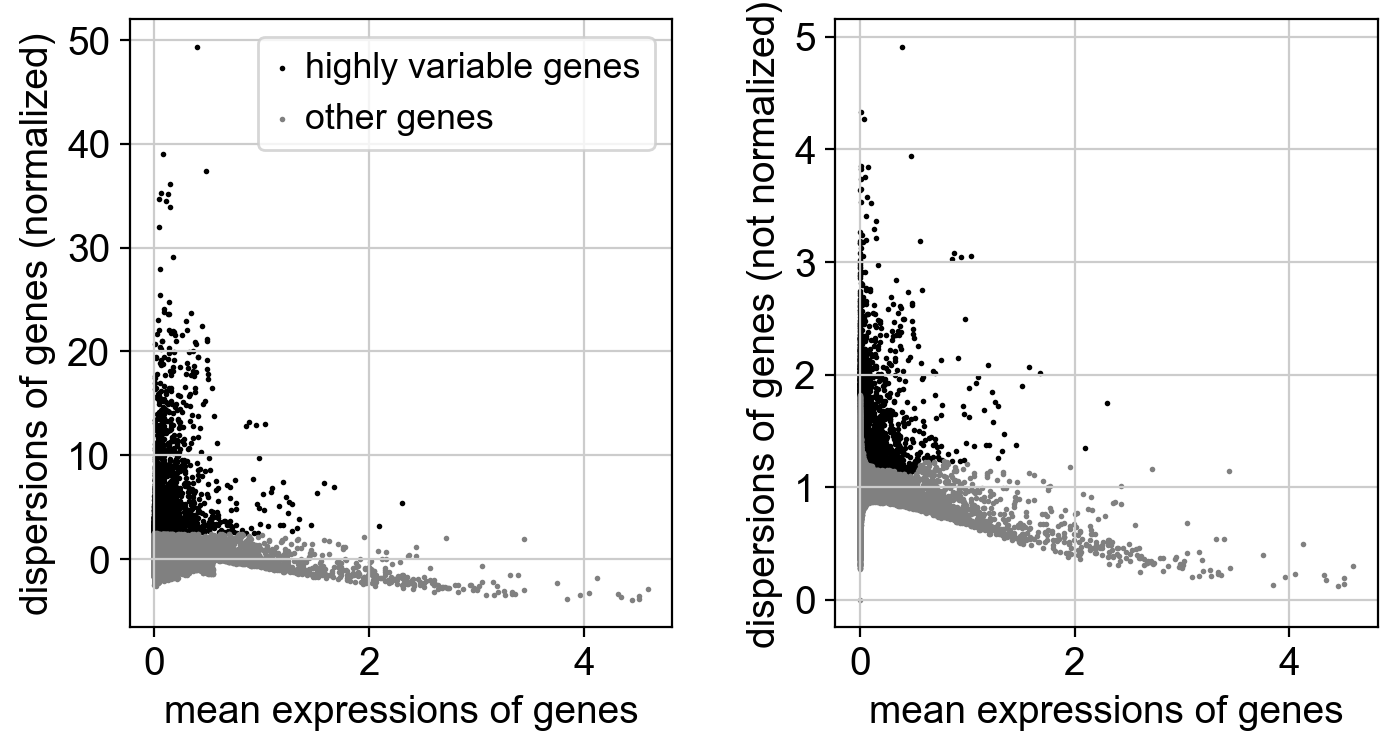

In [27]:
sc.pl.highly_variable_genes(adata, show=False)
plt.savefig(hvg_dir/"GSE203099_hvg.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.2 Regression and scaling

In [28]:
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
sc.pp.scale(adata, max_value=10)

regressing out ['total_counts', 'pct_counts_mt']
    finished (0:00:07)


Data were normalized and scaled to reduce technical variability associated with sequencing depth and mitochondrial content, while preserving biologically meaningful transcriptional differences.


## 6. Dimensionality reduction and clustering

### 6.1 Principal component analysis

computing PCA
    with n_comps=50
    finished (0:00:07)


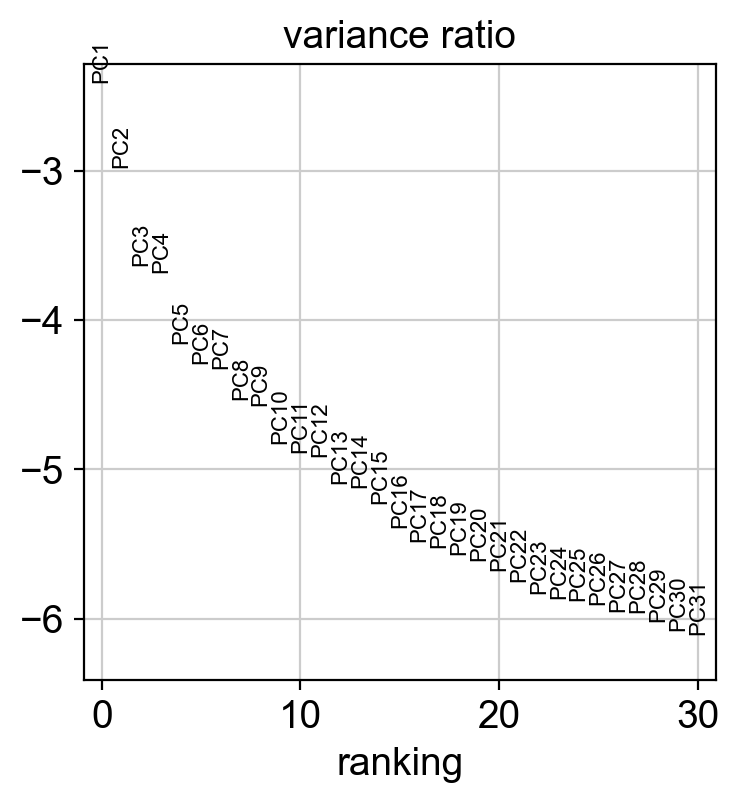

In [29]:
sc.tl.pca(
    adata,
    svd_solver="arpack",
    mask_var="highly_variable"
)
sc.pl.pca_variance_ratio(adata, log=True, show=False)
plt.savefig(dimred_dir/"pca_variance_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

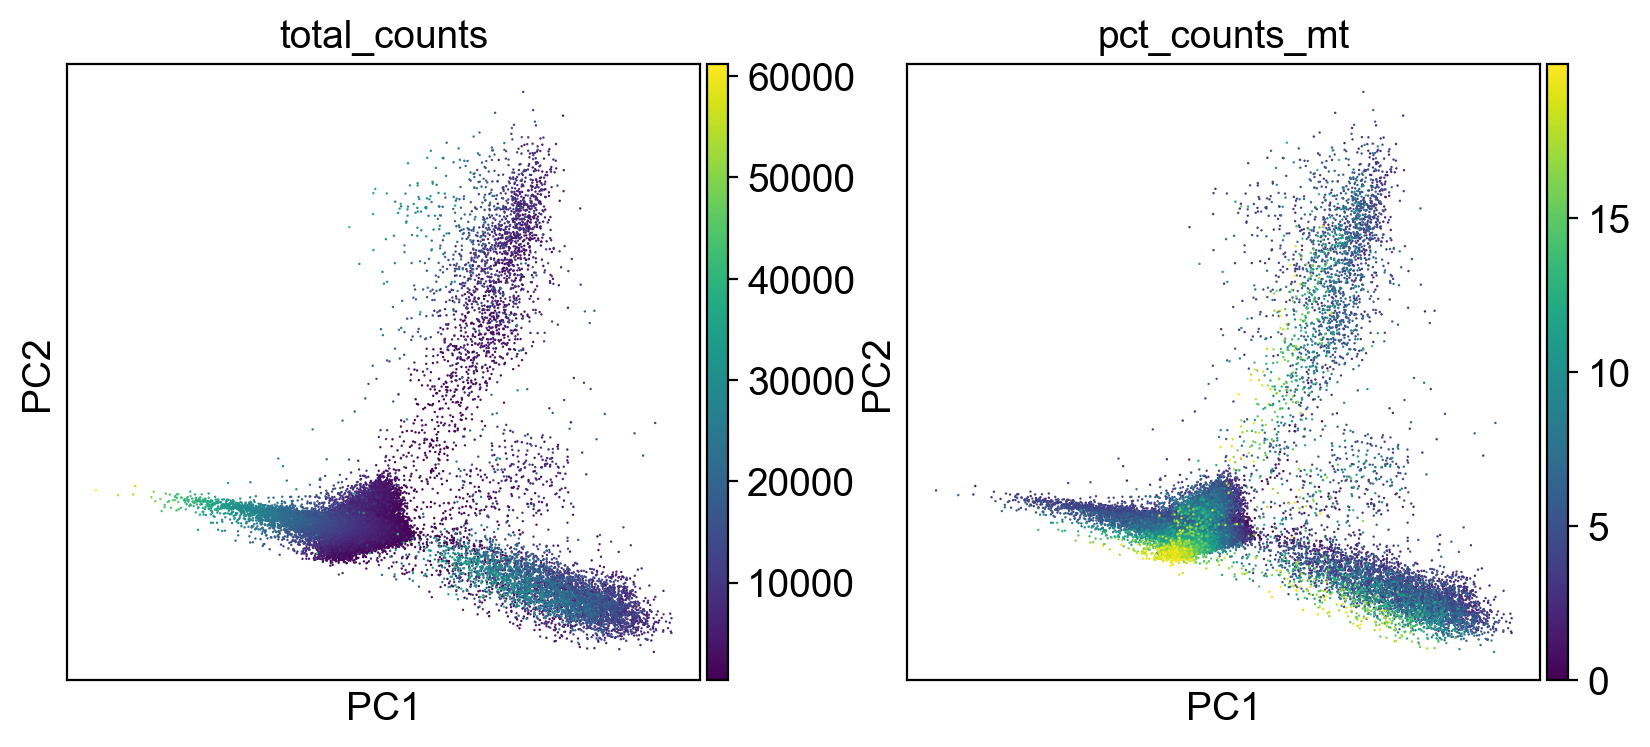

In [30]:
sc.pl.pca(adata, color=["total_counts", "pct_counts_mt"], show=False)
plt.savefig(dimred_dir/"pca_colored.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.2 Neighborhood graph and UMAP embedding

In [31]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:09)


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:44)


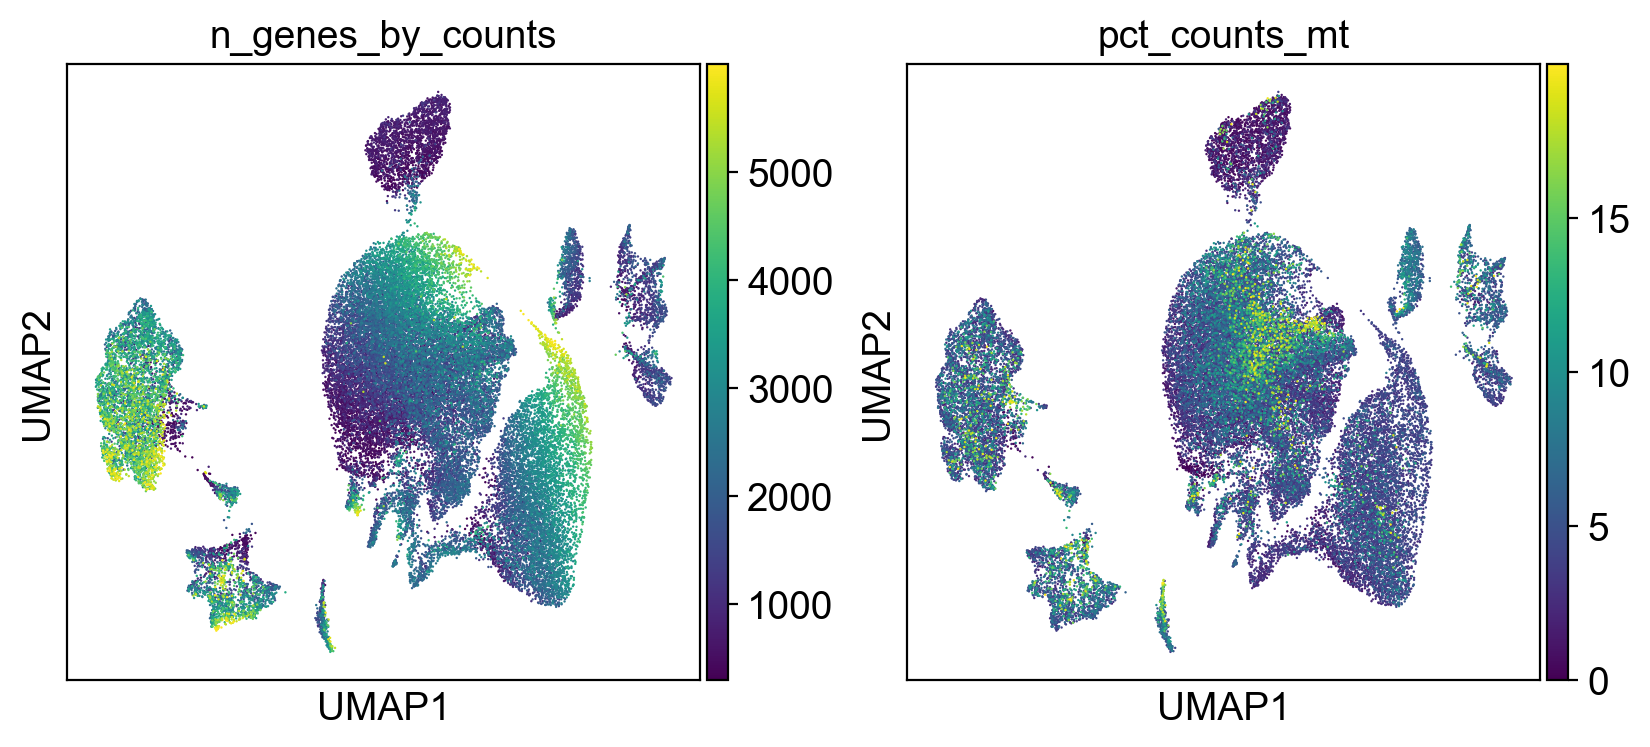

In [32]:
sc.tl.umap(adata)
sc.pl.umap(adata, color=["n_genes_by_counts", "pct_counts_mt"], show=False)
plt.savefig(dimred_dir/"umap_colored_by_qc.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.3 Graph-based clustering

In [33]:
sc.tl.leiden(
    adata,
    resolution=0.6,
    flavor="igraph",
    n_iterations=2,
    directed=False
)
adata.obs["leiden"].value_counts()

running Leiden clustering
    finished: found 17 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:02)


leiden
3     10872
0      6105
4      3266
7      3087
13     3059
10     2194
15     1766
2      1750
1      1607
11     1436
14     1432
5       967
6       810
9       569
12      515
16      348
8       256
Name: count, dtype: int64

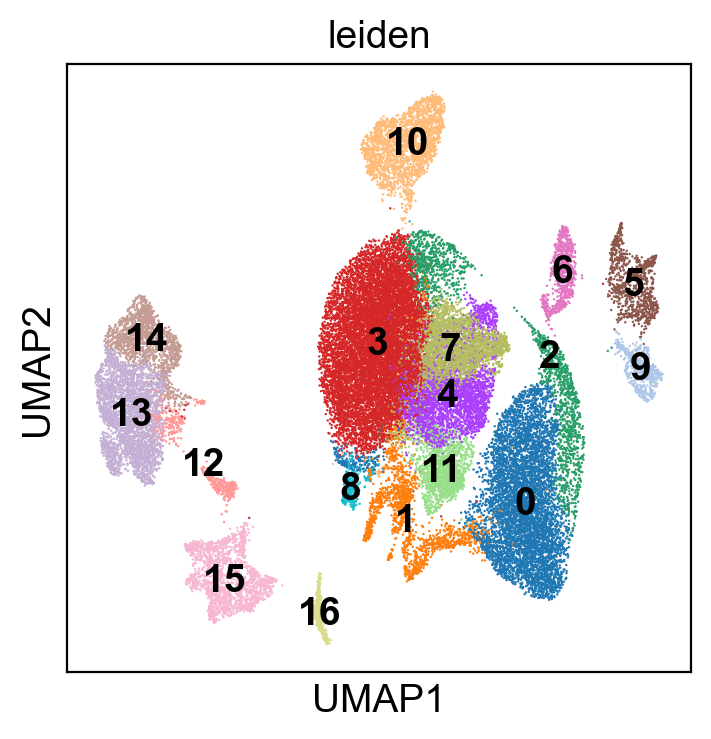

In [34]:
sc.pl.umap(adata, color="leiden", legend_loc="on data", show=False)
plt.savefig(clustering_dir/"umap_leiden.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Interpretation and transition

Unsupervised clustering revealed multiple transcriptionally distinct cellular populations, reflecting a heterogeneous immune and stromal response to biomaterial implantation. At this stage, clusters represent unbiased partitions of the global cellular landscape and are not yet assigned biological identities.

In [36]:
adata.write("../data/processed/GSE203099_clustered.h5ad")

Having established a high-quality, unbiased representation of the global cellular landscape, we next sought to assign biological identities to the major immune and stromal populations. The following analysis focuses on marker-based cell-type annotation and comparative immune composition across biomaterial conditions.
